# Econ 148 Final Project - Data Inspection

Track A, Topic 4: Intergenerational Mobility Across US Counties.
Team: Paul (data engineering), Kabir, Emily.

## Project scope

Our research question is: **what interactions between Chetty's five correlates of
intergenerational mobility (segregation, income inequality, school quality, social
capital, family structure) does a random forest capture that OLS misses?** To
answer it we need a county-level feature matrix and outcome vector, both built
from Opportunity Insights data.

This first notebook is strictly a data-inspection pass: we download the three
source files, load each into a pandas DataFrame, and verify that their FIPS
county identifiers line up so we can later merge features onto outcomes.

The three datasets loaded below are:

1. **Chetty et al. 2014 "Where is the Land of Opportunity?"** - online data tables
   Excel workbook. Online Data Table 3 is the county-level table of mobility
   statistics and income-distribution covariates that we load here; Online Data
   Tables 5 and 8 (commuting-zone correlates) are available in the same workbook
   for later use.
2. **Opportunity Atlas 2018 tract-level outcomes** - the "simple" variant of the
   Atlas tract file (~33 MB). Each row is a census tract; the `state`, `county`,
   and `tract` integer columns combine to a standard 11-digit tract FIPS, and
   rolling up to county FIPS is a single groupby away.
3. **Atlas county-level outcomes rollup** - a ready-made county-level version of
   the same Atlas outcomes. We use this as the day-1 outcome variable so that
   the modelling pipeline can start before tract-to-county aggregation is built.

## Imports and path setup

We pull in the standard scientific-Python stack plus our own `src.data_loader`
module. The path-discovery loop below walks up from the notebook's working
directory to find the project root (marked by the `.git` folder), so that
`from src.data_loader import ...` works whether the notebook is launched from
the project root or from the `notebooks/` subdirectory.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

_here = Path.cwd().resolve()
for _candidate in [_here, *_here.parents]:
    if (_candidate / 'src' / 'data_loader.py').exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from src.data_loader import (
    get_chetty_2014,
    get_opportunity_atlas_tract,
    get_county_outcomes,
)

print('pandas', pd.__version__, '  numpy', np.__version__)

pandas 3.0.1   numpy 2.4.3


## Download the three source files

Each `get_*` function:

- checks `data/raw/<filename>` and skips the download if a cached copy exists;
- otherwise tries each URL in its internal fallback list in order, logging every
  attempt (`try:` / `fail:` / `saved:`) so we can see which source actually served
  the file;
- prints the resulting file size on success.

The fallback lists in `src/data_loader.py` include the URLs originally named in
the project brief plus the `equality-of-opportunity.org` and `www2.census.gov`
mirrors, because several of the `opportunityinsights.org/wp-content/uploads/...`
paths were reorganized between 2018 and 2026 and now return 404 or 403.

In [2]:
chetty_path = get_chetty_2014()
tract_path  = get_opportunity_atlas_tract()
county_path = get_county_outcomes()

[1/3] Chetty 2014 descriptive tables:
  saved: chetty2014_online_data_tables.xls  (2.75 MB)
[2/3] Opportunity Atlas tract outcomes:
  saved: tract_outcomes_simple.csv  (32.81 MB)
[3/3] Atlas county-level outcomes:
  saved: county_outcomes_simple.csv  (1.65 MB)


## Dataset 1 of 3: Chetty et al. 2014 descriptive tables

**What we expect.** A multi-sheet Excel workbook. Online Data Table 3 is a
county-level table (~3,141 US counties) with columns including `County FIPS
Code`, `County Name`, `Commuting Zone ID`, `Rank-Rank Slope`, `Absolute Upward
Mobility`, `Gini`, `Teenage Birth Rate`, and various parent/child income
percentiles. We load this sheet as the first-pass feature set.

Online Data Tables 5-8 carry CZ-level data, including the famous five correlates
of mobility; we leave those for a later notebook once the team decides whether
to model at CZ or county resolution.

### 1a. Load the workbook

The header for Online Data Table 3 sits on row 30 of the raw sheet (0-indexed
29), preceded by title and explanatory-note rows, and followed by a short row of
column-number labels (`(1)`, `(2)`, ...) that we drop before the real data
begins. We also coerce numeric columns to numeric dtypes (pandas otherwise
leaves them as `object` because of the dropped label row).

In [3]:
chetty_df = pd.read_excel(
    chetty_path,
    sheet_name='Online Data Table 3',
    skiprows=29,
    header=0,
)
chetty_df = chetty_df.iloc[1:].reset_index(drop=True)

_text_cols = {'County Name', 'Commuting Zone Name ', 'State'}
for _c in chetty_df.columns:
    if _c not in _text_cols:
        chetty_df[_c] = pd.to_numeric(chetty_df[_c], errors='coerce')

chetty_df.head(3)

,County FIPS Code,County Name,Commuting Zone ID,Commuting Zone Name,State,Number of Children in Core Sample,Rank-Rank Slope,Absolute Upward Mobility,Top 1% Income Share,Interquartile Income Range,...,Parent Income P25,Child Income P25,Median Parent Income,Median Child Income,Parent Income P75,Child Income P75,Parent Income P90,Child Income P90,Parent Income P99,Child Income P99
0,1001,Autauga,11101,Montgomery,Alabama,1846.0,0.44377,38.38125,0.06143,60882.38,...,26900.0,13700.0,53900.0,31900.0,87700.0,62100.0,121600.0,90400.0,227400.0,158000.0
1,1003,Baldwin,11001,Mobile,Alabama,5061.0,0.33610,39.64750,0.12719,63853.73,...,26600.0,13400.0,53600.0,30200.0,90500.0,59500.0,135600.0,93900.0,444500.0,194500.0
2,1005,Barbour,10301,Eufaula,Alabama,1129.0,0.39817,36.11125,0.09734,41923.99,...,18900.0,10400.0,32000.0,22400.0,60800.0,44600.0,105600.0,75800.0,235700.0,153400.0


### 1b. Shape, info, and head

A quick structural inspection: row and column counts, per-column dtypes and
non-null counts, and the first five records.

In [4]:
print('shape:', chetty_df.shape)
print()
chetty_df.info()
print()
chetty_df.head()

shape: (3141, 25)

<class 'pandas.DataFrame'>
RangeIndex: 3141 entries, 0 to 3140
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   County FIPS Code                   3141 non-null   int64  
 1   County Name                        3141 non-null   str    
 2   Commuting Zone ID                  3141 non-null   int64  
 3   Commuting Zone Name                3141 non-null   str    
 4   State                              3141 non-null   str    
 5   Number of Children in Core Sample  2769 non-null   float64
 6   Rank-Rank Slope                    2769 non-null   float64
 7   Absolute Upward Mobility           2769 non-null   float64
 8   Top 1% Income Share                2769 non-null   float64
 9   Interquartile Income Range         2769 non-null   float64
 10  Gini                               2769 non-null   float64
 11  Teenage Birth Rate                 2769 non-null

,County FIPS Code,County Name,Commuting Zone ID,Commuting Zone Name,State,Number of Children in Core Sample,Rank-Rank Slope,Absolute Upward Mobility,Top 1% Income Share,Interquartile Income Range,...,Parent Income P25,Child Income P25,Median Parent Income,Median Child Income,Parent Income P75,Child Income P75,Parent Income P90,Child Income P90,Parent Income P99,Child Income P99
0,1001,Autauga,11101,Montgomery,Alabama,1846.0,0.44377,38.38125,0.06143,60882.38,...,26900.0,13700.0,53900.0,31900.0,87700.0,62100.0,121600.0,90400.0,227400.0,158000.0
1,1003,Baldwin,11001,Mobile,Alabama,5061.0,0.33610,39.64750,0.12719,63853.73,...,26600.0,13400.0,53600.0,30200.0,90500.0,59500.0,135600.0,93900.0,444500.0,194500.0
2,1005,Barbour,10301,Eufaula,Alabama,1129.0,0.39817,36.11125,0.09734,41923.99,...,18900.0,10400.0,32000.0,22400.0,60800.0,44600.0,105600.0,75800.0,235700.0,153400.0
3,1007,Bibb,10801,Tuscaloosa,Alabama,841.0,0.43440,39.08400,0.06622,52495.53,...,18300.0,11600.0,36500.0,26800.0,70800.0,57100.0,98300.0,89300.0,204300.0,165600.0
4,1009,Blount,10700,Birmingham,Alabama,1224.0,0.31711,41.97575,0.06281,46597.95,...,28100.0,13900.0,50200.0,33200.0,74700.0,61300.0,101400.0,87000.0,213900.0,159800.0


### 1c. FIPS column in Chetty 2014

Scan the columns for anything that looks like a county identifier (`FIPS`,
`cty`, `county`, `statecounty`, or a value that is a 2-digit state + 3-digit
county pattern). Report its dtype, a sample of five non-null values, and the
percentage missing.

In [5]:
_candidates = [c for c in chetty_df.columns
               if any(k in c.lower() for k in ('fips', 'cty', 'county', 'statecounty'))]
print('candidate FIPS-like columns:', _candidates)

chetty_fips_col = 'County FIPS Code'
_values = chetty_df[chetty_fips_col]

print()
print('chosen column:', chetty_fips_col)
print('dtype:        ', _values.dtype)
print('sample of 5:  ', _values.dropna().sample(5, random_state=0).astype(int).tolist())
print('pct missing:   {:.3%}'.format(_values.isna().mean()))

candidate FIPS-like columns: ['County FIPS Code', 'County Name']

chosen column: County FIPS Code
dtype:         int64
sample of 5:   [29021, 27105, 8097, 37193, 25017]
pct missing:   0.000%


## Dataset 2 of 3: Opportunity Atlas tract-level outcomes

**What we expect.** ~73,000 rows (one per US census tract) and ~64 columns of
pooled and race/gender-disaggregated mobility estimates. The key outcome column
is `kfr_pooled_pooled_p25` (mean child rank at parent p25). Tract identification
is split across three integer columns: `state` (1-56 FIPS state), `county` (the
3-digit county-within-state FIPS), and `tract` (the 6-digit tract-within-county
FIPS).

### 2a. Load the tract CSV

In [6]:
tract_df = pd.read_csv(tract_path)
tract_df.head(3)

,state,county,tract,cz,czname,kfr_pooled_pooled_p25,kfr_pooled_pooled_p25_se,jail_pooled_pooled_p25,jail_pooled_pooled_p25_se,pooled_pooled_count,...,jail_hisp_male_p25,jail_hisp_male_p25_se,jail_white_male_p25,jail_white_male_p25_se,white_male_count,black_male_count,hisp_male_count,white_female_count,black_female_count,hisp_female_count
0,1,1,20100,11101.0,Montgomery,0.367813,0.021693,0.031844,0.020345,228.14854,...,NaN,NaN,0.069903,0.035733,101.021520,NaN,NaN,89.647583,NaN,NaN
1,1,1,20200,11101.0,Montgomery,0.316781,0.014647,0.049013,0.019211,391.91345,...,NaN,NaN,0.002691,0.029357,32.695038,150.244080,NaN,46.506416,139.571000,NaN
2,1,1,20300,11101.0,Montgomery,0.373485,0.018376,0.030266,0.015061,394.79211,...,NaN,NaN,0.019237,0.013509,156.940720,50.579407,NaN,108.949490,49.571842,NaN


### 2b. Shape, info, and head

With ~64 columns we pass `verbose=True, show_counts=True` so `info()` prints
per-column non-null counts instead of a summary.

In [7]:
print('shape:', tract_df.shape)
print()
tract_df.info(verbose=True, show_counts=True)
print()
tract_df.head()

shape: (73278, 65)

<class 'pandas.DataFrame'>
RangeIndex: 73278 entries, 0 to 73277
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   state                      73278 non-null  int64  
 1   county                     73278 non-null  int64  
 2   tract                      73278 non-null  int64  
 3   cz                         72552 non-null  float64
 4   czname                     72552 non-null  str    
 5   kfr_pooled_pooled_p25      72014 non-null  float64
 6   kfr_pooled_pooled_p25_se   72014 non-null  float64
 7   jail_pooled_pooled_p25     71880 non-null  float64
 8   jail_pooled_pooled_p25_se  71880 non-null  float64
 9   pooled_pooled_count        71950 non-null  float64
 10  kfr_black_pooled_p25       34088 non-null  float64
 11  kfr_black_pooled_p25_se    34085 non-null  float64
 12  kfr_hisp_pooled_p25        37618 non-null  float64
 13  kfr_hisp_pooled_p25_se     37611 non-

,state,county,tract,cz,czname,kfr_pooled_pooled_p25,kfr_pooled_pooled_p25_se,jail_pooled_pooled_p25,jail_pooled_pooled_p25_se,pooled_pooled_count,...,jail_hisp_male_p25,jail_hisp_male_p25_se,jail_white_male_p25,jail_white_male_p25_se,white_male_count,black_male_count,hisp_male_count,white_female_count,black_female_count,hisp_female_count
0,1,1,20100,11101.0,Montgomery,0.367813,0.021693,0.031844,0.020345,228.14854,...,NaN,NaN,0.069903,0.035733,101.021520,NaN,NaN,89.647583,NaN,NaN
1,1,1,20200,11101.0,Montgomery,0.316781,0.014647,0.049013,0.019211,391.91345,...,NaN,NaN,0.002691,0.029357,32.695038,150.244080,NaN,46.506416,139.571000,NaN
2,1,1,20300,11101.0,Montgomery,0.373485,0.018376,0.030266,0.015061,394.79211,...,NaN,NaN,0.019237,0.013509,156.940720,50.579407,NaN,108.949490,49.571842,NaN
3,1,1,20400,11101.0,Montgomery,0.421511,0.019321,0.033916,0.014419,388.38309,...,NaN,NaN,0.018265,0.011083,181.365370,NaN,NaN,169.048230,NaN,NaN
4,1,1,20500,11101.0,Montgomery,0.433415,0.020093,0.013398,0.007040,419.08334,...,NaN,NaN,0.026169,0.014869,193.299360,28.388056,NaN,140.759220,21.622227,NaN


### 2c. FIPS column in the tract file

There is no single FIPS column: identifiers are split across `state`, `county`,
and `tract`. We derive a standard 5-digit county FIPS as `state * 1000 +
county`, which matches the packed integer representation used by Chetty 2014
Online Data Table 3 (e.g. Alabama / Autauga = 1001). The 11-digit tract FIPS
(`state * 1e9 + county * 1e6 + tract`) will become useful when we aggregate
tracts to counties in a later notebook.

In [8]:
tract_df['county_fips'] = tract_df['state'] * 1000 + tract_df['county']

_candidates = [c for c in tract_df.columns
               if any(k in c.lower() for k in ('fips', 'cty', 'county', 'statecounty'))]
print('candidate FIPS-like columns:', _candidates)

print()
print('chosen column: county_fips (derived = state*1000 + county)')
print('dtype:        ', tract_df['county_fips'].dtype)
print('sample of 5:  ', tract_df['county_fips'].dropna().sample(5, random_state=0).astype(int).tolist())
print('unique counties represented:', tract_df['county_fips'].nunique())
print('pct missing:   {:.3%}'.format(tract_df['county_fips'].isna().mean()))

candidate FIPS-like columns: ['county', 'county_fips']

chosen column: county_fips (derived = state*1000 + county)
dtype:         int64
sample of 5:   [4013, 18141, 47157, 55131, 37183]
unique counties represented: 3219
pct missing:   0.000%


## Dataset 3 of 3: Atlas county-level outcomes (day-1 outcome)

**What we expect.** One row per county (~3,219 rows) with the same outcome
columns as the tract file but pre-aggregated. This is the day-1 outcome
variable: it lets us start fitting models without implementing the
tract-to-county aggregation first. The identifier columns are `state` (2-digit
FIPS) and `county` (3-digit FIPS).

### 3a. Load the county CSV

In [9]:
county_df = pd.read_csv(county_path)
county_df.head(3)

,state,county,cz,czname,kfr_pooled_pooled_p25,kfr_pooled_pooled_p25_se,jail_pooled_pooled_p25,jail_pooled_pooled_p25_se,pooled_pooled_count,kfr_black_pooled_p25,...,jail_hisp_male_p25,jail_hisp_male_p25_se,jail_white_male_p25,jail_white_male_p25_se,white_male_count,black_male_count,hisp_male_count,white_female_count,black_female_count,hisp_female_count
0,1,1,11101.0,Montgomery,0.361666,0.005026,0.030568,0.004108,5922.3921,0.307032,...,0.057968,0.057395,0.025038,0.006608,1874.46810,989.14886,50.308254,1739.24780,989.09662,54.077316
1,1,3,11001.0,Mobile,0.388847,0.003599,0.022593,0.002463,15458.3960,0.301880,...,0.054038,0.034066,0.029861,0.004701,5544.37500,1964.96840,218.435900,5226.07810,1916.26940,210.060300
2,1,5,10301.0,Eufaula,0.349386,0.005937,0.033516,0.005712,4863.9736,0.308615,...,NaN,NaN,0.009500,0.006570,729.84253,1787.36910,NaN,629.64722,1806.09170,NaN


### 3b. Shape, info, and head

In [10]:
print('shape:', county_df.shape)
print()
county_df.info(verbose=True, show_counts=True)
print()
county_df.head()

shape: (3219, 64)

<class 'pandas.DataFrame'>
RangeIndex: 3219 entries, 0 to 3218
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   state                      3219 non-null   int64  
 1   county                     3219 non-null   int64  
 2   cz                         3140 non-null   float64
 3   czname                     3140 non-null   str    
 4   kfr_pooled_pooled_p25      3208 non-null   float64
 5   kfr_pooled_pooled_p25_se   3208 non-null   float64
 6   jail_pooled_pooled_p25     3184 non-null   float64
 7   jail_pooled_pooled_p25_se  3184 non-null   float64
 8   pooled_pooled_count        3134 non-null   float64
 9   kfr_black_pooled_p25       1915 non-null   float64
 10  kfr_black_pooled_p25_se    1915 non-null   float64
 11  kfr_hisp_pooled_p25        2383 non-null   float64
 12  kfr_hisp_pooled_p25_se     2383 non-null   float64
 13  kfr_white_pooled_p25       3131 non-null

,state,county,cz,czname,kfr_pooled_pooled_p25,kfr_pooled_pooled_p25_se,jail_pooled_pooled_p25,jail_pooled_pooled_p25_se,pooled_pooled_count,kfr_black_pooled_p25,...,jail_hisp_male_p25,jail_hisp_male_p25_se,jail_white_male_p25,jail_white_male_p25_se,white_male_count,black_male_count,hisp_male_count,white_female_count,black_female_count,hisp_female_count
0,1,1,11101.0,Montgomery,0.361666,0.005026,0.030568,0.004108,5922.3921,0.307032,...,0.057968,0.057395,0.025038,0.006608,1874.46810,989.14886,50.308254,1739.24780,989.096620,54.077316
1,1,3,11001.0,Mobile,0.388847,0.003599,0.022593,0.002463,15458.3960,0.301880,...,0.054038,0.034066,0.029861,0.004701,5544.37500,1964.96840,218.435900,5226.07810,1916.269400,210.060300
2,1,5,10301.0,Eufaula,0.349386,0.005937,0.033516,0.005712,4863.9736,0.308615,...,NaN,NaN,0.009500,0.006570,729.84253,1787.36910,NaN,629.64722,1806.091700,NaN
3,1,7,10801.0,Tuscaloosa,0.363391,0.008233,0.031667,0.007499,3061.4934,0.309438,...,NaN,NaN,0.038612,0.013741,983.28558,613.93317,NaN,941.44788,565.889710,NaN
4,1,9,10700.0,Birmingham,0.391879,0.005882,0.020528,0.003750,6740.9116,0.310179,...,0.037591,0.027402,0.034564,0.007016,2946.53000,71.30426,442.633730,2779.32890,64.377319,411.615330


### 3c. FIPS column in the county file

Same `state`/`county` integer split as the tract file; we build the 5-digit key
`county_fips = state * 1000 + county` and report missingness for both the key
and the main outcome `kfr_pooled_pooled_p25`.

In [11]:
county_df['county_fips'] = county_df['state'] * 1000 + county_df['county']

_candidates = [c for c in county_df.columns
               if any(k in c.lower() for k in ('fips', 'cty', 'county', 'statecounty'))]
print('candidate FIPS-like columns:', _candidates)

print()
print('chosen column: county_fips (derived = state*1000 + county)')
print('dtype:        ', county_df['county_fips'].dtype)
print('sample of 5:  ', county_df['county_fips'].dropna().sample(5, random_state=0).astype(int).tolist())
print('pct missing county_fips:            {:.3%}'.format(county_df['county_fips'].isna().mean()))
print('pct missing kfr_pooled_pooled_p25:  {:.3%}'.format(county_df['kfr_pooled_pooled_p25'].isna().mean()))

candidate FIPS-like columns: ['county', 'county_fips']

chosen column: county_fips (derived = state*1000 + county)
dtype:         int64
sample of 5:   [13285, 19191, 47173, 54081, 42049]
pct missing county_fips:            0.000%
pct missing kfr_pooled_pooled_p25:  0.342%


## Cross-dataset FIPS compatibility check

The three datasets will be merged on 5-digit county FIPS. Below we compute the
pairwise and three-way intersections of the FIPS key sets and count any counties
that appear in some frames but not others. A clean merge requires every county
we care about to be present in all three.

In [12]:
chetty_fips_set = set(chetty_df['County FIPS Code'].dropna().astype(int).tolist())
tract_fips_set  = set(tract_df['county_fips'].dropna().astype(int).unique().tolist())
county_fips_set = set(county_df['county_fips'].dropna().astype(int).tolist())

print('Unique counties per dataset:')
print(f'  Chetty 2014 Online Data Table 3:   {len(chetty_fips_set):>5}')
print(f'  Atlas tract file (rolled to cty):  {len(tract_fips_set):>5}')
print(f'  Atlas county outcomes rollup:      {len(county_fips_set):>5}')

all_three    = chetty_fips_set & tract_fips_set & county_fips_set
chetty_only  = chetty_fips_set - (tract_fips_set | county_fips_set)
outcome_only = county_fips_set - chetty_fips_set
tract_only   = tract_fips_set - chetty_fips_set

print()
print(f'Counties in ALL three:                 {len(all_three):>5}')
print(f'Counties in Chetty only (no outcome):  {len(chetty_only):>5}')
print(f'Counties in Atlas but not Chetty:      {len(outcome_only):>5}')
print(f'Counties in tract but not Chetty:      {len(tract_only):>5}')

Unique counties per dataset:
  Chetty 2014 Online Data Table 3:    3141
  Atlas tract file (rolled to cty):   3219
  Atlas county outcomes rollup:       3219

Counties in ALL three:                  3133
Counties in Chetty only (no outcome):      8
Counties in Atlas but not Chetty:         86
Counties in tract but not Chetty:         86


## Summary for Leo (Progress Report input)

A concise three-sentence data-engineering summary to paste into the Progress
Report. Regenerated from live data each time the notebook is run, so numbers
stay in sync with the frames above.

In [13]:
chetty_na_pct = chetty_df['County FIPS Code'].isna().mean()
outcome_na_pct = county_df['kfr_pooled_pooled_p25'].isna().mean()
shared = len(chetty_fips_set & county_fips_set)
only_chetty = len(chetty_fips_set - county_fips_set)
only_outcome = len(county_fips_set - chetty_fips_set)

summary = (
    f"(1) All three Opportunity Insights datasets downloaded and loaded: Chetty 2014 "
    f"Online Data Table 3 (county-level mobility and income covariates), the "
    f"Opportunity Atlas tract-level outcomes (simple variant, ~33 MB), and the "
    f"Atlas county-level outcome rollup. "
    f"(2) Row x column counts are {chetty_df.shape} for Chetty 2014, "
    f"{tract_df.shape} for the tract file, and {county_df.shape} for the county "
    f"outcomes; they share a 5-digit county FIPS key on which {shared} counties "
    f"intersect between the Chetty feature file and the outcome file. "
    f"(3) Flagged issues: Chetty FIPS is {chetty_na_pct:.2%} missing and the main "
    f"outcome kfr_pooled_pooled_p25 is {outcome_na_pct:.2%} missing, with "
    f"{only_chetty} Chetty counties lacking an Atlas outcome and {only_outcome} "
    f"Atlas counties lacking Chetty covariates; we will decide between dropping or "
    f"imputing these in the next step."
)
print(summary)

(1) All three Opportunity Insights datasets downloaded and loaded: Chetty 2014 Online Data Table 3 (county-level mobility and income covariates), the Opportunity Atlas tract-level outcomes (simple variant, ~33 MB), and the Atlas county-level outcome rollup. (2) Row x column counts are (3141, 25) for Chetty 2014, (73278, 66) for the tract file, and (3219, 65) for the county outcomes; they share a 5-digit county FIPS key on which 3133 counties intersect between the Chetty feature file and the outcome file. (3) Flagged issues: Chetty FIPS is 0.00% missing and the main outcome kfr_pooled_pooled_p25 is 0.34% missing, with 8 Chetty counties lacking an Atlas outcome and 86 Atlas counties lacking Chetty covariates; we will decide between dropping or imputing these in the next step.


## CZ-level covariates merge preview

Purpose: preview the feature matrix that the OLS specification will use. Our
features are Chetty's "famous five" CZ-level covariates (racial and income
segregation, income inequality, school quality, social capital, family
structure) and related CZ characteristics, and the outcome is
`kfr_pooled_pooled_p25` on the county frame. This section loads the covariates,
loads the county-to-CZ crosswalk, performs the left merge, and reports match
rate and the final feature column list.

Note on sheet selection in the 2014 workbook: the project brief referred to
"Online Data Table 5" for the famous five covariates. In the published
workbook Online Data Table 5 actually holds CZ-level mobility *estimates*
(rank-rank slope, absolute upward mobility, college attendance rates at parent
p25), while the CZ-level *covariates* used in the correlation analysis of
Chetty et al. (2014) Section V live in Online Data Table 8 ("Commuting Zone
Characteristics"). We load Table 8 here because the merge preview requires
covariates. If the team prefers to also pull Table 5's mobility estimates at
CZ level for a secondary regression, the loader can be reused with
`sheet_name='Online Data Table 5'` in a future notebook.

### 4a. Load the CZ-level covariates (Online Data Table 8)

Table 8's header sits on row 7 of the raw sheet (0-indexed 6); row 8 is a short
column-number row that we drop before the real data starts. Numeric columns
are coerced with `pd.to_numeric(errors='coerce')` because the dropped row
forces pandas to infer `object` dtype for the entire column.

In [14]:
cz_cov_df = pd.read_excel(
    chetty_path,
    sheet_name='Online Data Table 8',
    skiprows=6,
    header=0,
)
cz_cov_df = cz_cov_df.iloc[1:].reset_index(drop=True)

_cz_cov_text_cols = {'CZ Name', 'State'}
for _c in cz_cov_df.columns:
    if _c not in _cz_cov_text_cols:
        cz_cov_df[_c] = pd.to_numeric(cz_cov_df[_c], errors='coerce')

print('CZ covariates shape:', cz_cov_df.shape)
print('first 8 columns:    ', list(cz_cov_df.columns)[:8])
cz_cov_df.head(3)

CZ covariates shape: (741, 41)
first 8 columns:     ['CZ', 'CZ Name', 'State', 'Census 2000 population', 'Urban Areas', 'Frac. Black', 'Racial Segregation', 'Income Segregation']


,CZ,CZ Name,State,Census 2000 population,Urban Areas,Frac. Black,Racial Segregation,Income Segregation,Segregation of Poverty (<p25),Segregation of Affluence (>p75),...,Migration Inflow Rate,Migration Outlflow Rate,Frac. Foreign Born,Social Capital Index,Fraction Religious,Violent Crime Rate,Fraction of Children with Single Mothers,Fraction of Adults Divorced,Fraction of Adults Married,Income Growth 2000-2006/10
0,100,Johnson City,TN,576081,1,0.020841,0.090384,0.034866,0.030153,0.038240,...,0.005640,0.004697,0.011784,-0.297858,0.514403,0.001409,0.189803,0.110173,0.600893,-0.002278
1,200,Morristown,TN,227816,1,0.019779,0.093153,0.026281,0.027858,0.025335,...,0.016206,0.014235,0.023055,-0.767355,0.543895,0.001844,0.185106,0.115958,0.613359,-0.002153
2,301,Middlesborough,TN,66708,0,0.014646,0.064250,0.024081,0.014683,0.025814,...,0.008050,0.011603,0.007078,-1.270251,0.667806,0.000855,0.211003,0.113451,0.590280,-0.003712


### 4b. Download and load the county-to-CZ crosswalk

The crosswalk maps each 5-digit county FIPS (`cty`) to its commuting-zone id
(`cz`). We use it as the authoritative county-to-CZ mapping for the merge
(rather than trusting the `cz` column already present on the county outcomes
file), so that the pipeline also works for datasets that arrive without a
pre-attached CZ column.

In [15]:
from src.data_loader import download_cz_crosswalk

crosswalk_path = download_cz_crosswalk()
crosswalk_df = pd.read_csv(crosswalk_path)
print('crosswalk shape:', crosswalk_df.shape)
print('cols:           ', list(crosswalk_df.columns))
crosswalk_df.head(3)

[+]   County-to-CZ crosswalk:
  saved: cty_cz_st_crosswalk.csv  (0.13 MB)
crosswalk shape: (3138, 7)
cols:            ['cty', 'county_name', 'cz', 'cz_name', 'statename', 'state_fips', 'stateabbrv']


,cty,county_name,cz,cz_name,statename,state_fips,stateabbrv
0,1001,Autauga,11101,Montgomery,Alabama,1,AL
1,1003,Baldwin,11001,Mobile,Alabama,1,AL
2,1005,Barbour,10301,Eufaula,Alabama,1,AL


### 4c. Left-merge CZ covariates onto the county frame

Two-step merge so the provenance of every column is explicit:

1. Attach the crosswalk's `cz` onto `county_df` using `county_fips` as the key.
2. Attach `cz_cov_df` (Online Data Table 8) onto that intermediate frame using
   `cz` as the key.

Left join at each step so every original county row is preserved; unmatched
rows will carry `NaN` in the covariate columns and will surface in the match-
rate check below.

In [16]:
_cw_narrow = crosswalk_df[['cty', 'cz']].rename(columns={'cty': 'county_fips', 'cz': 'cz_from_crosswalk'})
county_with_cz = county_df.merge(_cw_narrow, on='county_fips', how='left')

_cz_cov_for_merge = cz_cov_df.rename(columns={'CZ': 'cz_from_crosswalk'})
merged_df = county_with_cz.merge(_cz_cov_for_merge, on='cz_from_crosswalk', how='left')

print('county_df shape before merge:          ', county_df.shape)
print('+ crosswalk cz attached:                ', county_with_cz.shape)
print('+ Table 8 CZ covariates left-joined:    ', merged_df.shape)

county_df shape before merge:           (3219, 65)
+ crosswalk cz attached:                 (3219, 66)
+ Table 8 CZ covariates left-joined:     (3219, 106)


### 4d. Match rate and merged feature columns

We quantify the merge quality two ways. First, the share of county rows that
received a non-null CZ id from the crosswalk. Second, the share of county rows
whose first CZ-level covariate (`Racial Segregation`, a proxy for "all CZ
covariates merged on successfully") is non-null after the join. The second
number is the one to cite when talking about how many counties the OLS spec
will actually see.

In [17]:
cz_match = merged_df['cz_from_crosswalk'].notna().mean()
cov_match = merged_df['Racial Segregation'].notna().mean()

_cov_feature_cols = [c for c in cz_cov_df.columns if c not in ('CZ', 'CZ Name', 'State')]

print(f'Rows in merged county frame:                 {len(merged_df)}')
print(f'County rows with CZ id from crosswalk:       {merged_df["cz_from_crosswalk"].notna().sum()}  '
      f'({cz_match:.2%})')
print(f'County rows with non-null CZ covariates:     {merged_df["Racial Segregation"].notna().sum()}  '
      f'({cov_match:.2%})')
print()
print(f'Merged CZ-covariate feature columns ({len(_cov_feature_cols)}):')
for _c in _cov_feature_cols:
    print(f'  - {_c}')

Rows in merged county frame:                 3219
County rows with CZ id from crosswalk:       3130  (97.24%)
County rows with non-null CZ covariates:     3130  (97.24%)

Merged CZ-covariate feature columns (38):
  - Census 2000 population
  - Urban Areas
  - Frac. Black
  - Racial Segregation
  - Income Segregation
  - Segregation of Poverty (<p25)
  - Segregation of Affluence (>p75)
  - Frac. with Commute < 15 Mins
  - Household Income per capita
  - Gini
  - Top 1% Income Share
  - Gini Bottom 99%
  - Frac. Between p25 and p75
  - Local Tax Rate
  - Local Government Expenditures Per Capita
  - State Income Tax Progressivity
  - State EITC Exposure
  - School Expenditure per Student
  - Teacher Student Ratio
  - Test Score Percentile (Income Adjusted
  - High School Dropout Rate (Income Adjusted)
  - Number of Colleges per Capita
  - College Tuition
  - College Graduation Rate (Income Adjusted)
  - Labor Force Participation Rate
  - Manufacturing Employment Share
  - Growth in Chines

## 5. Outcome distribution and predictor correlations

Two diagnostic figures requested by Leo for the GitHub-rendered notebook: a
histogram of the county-level outcome `kfr_pooled_pooled_p25`, and a Pearson
correlation heatmap over the six OLS-spec predictors plus the outcome. Both
are computed on the merged frame from section 4 (3,130 counties remaining
after the unmatched-county drop).

### 5a. Histogram of `kfr_pooled_pooled_p25`

`kfr_pooled_pooled_p25` is the mean adult income rank for children whose
parents were at the 25th percentile of the national family-income
distribution. We plot the raw across-county distribution with the mean and
median annotated, save the figure to `report/outcome_histogram.png`, and
display it inline so the GitHub-rendered notebook embeds the image.

saved: /Users/paullin/Desktop/econ148-final/report/outcome_histogram.png


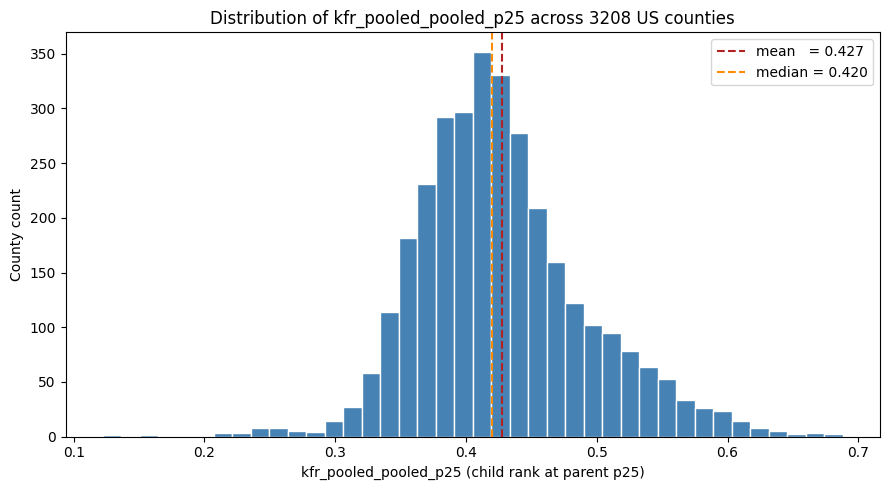

In [18]:
import matplotlib.pyplot as plt

_proj_root = next(c for c in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
                  if (c / 'src' / 'data_loader.py').exists())

_y = merged_df['kfr_pooled_pooled_p25'].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(_y, bins=40, color='steelblue', edgecolor='white')
ax.axvline(_y.mean(),   color='firebrick', linestyle='--', linewidth=1.5, label=f'mean   = {_y.mean():.3f}')
ax.axvline(_y.median(), color='darkorange', linestyle='--', linewidth=1.5, label=f'median = {_y.median():.3f}')
ax.set(xlabel='kfr_pooled_pooled_p25 (child rank at parent p25)',
       ylabel='County count',
       title=f'Distribution of kfr_pooled_pooled_p25 across {len(_y)} US counties')
ax.legend(loc='upper right')
fig.tight_layout()

_hist_path = _proj_root / 'report' / 'outcome_histogram.png'
_hist_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_hist_path, dpi=144, bbox_inches='tight')
print(f'saved: {_hist_path}')
plt.show()

### 5b. Correlation heatmap for the six OLS predictors plus the outcome

Pearson pairwise correlations across the six covariates that enter Kabir's
OLS specification plus the outcome, computed on the cleaned merged frame.
Annotated cells make the magnitudes legible without a separate table; the
diverging red-blue colormap centres on zero so positive and negative
correlations of the same strength have visually balanced intensity.

saved: /Users/paullin/Desktop/econ148-final/report/predictor_correlation_heatmap.png


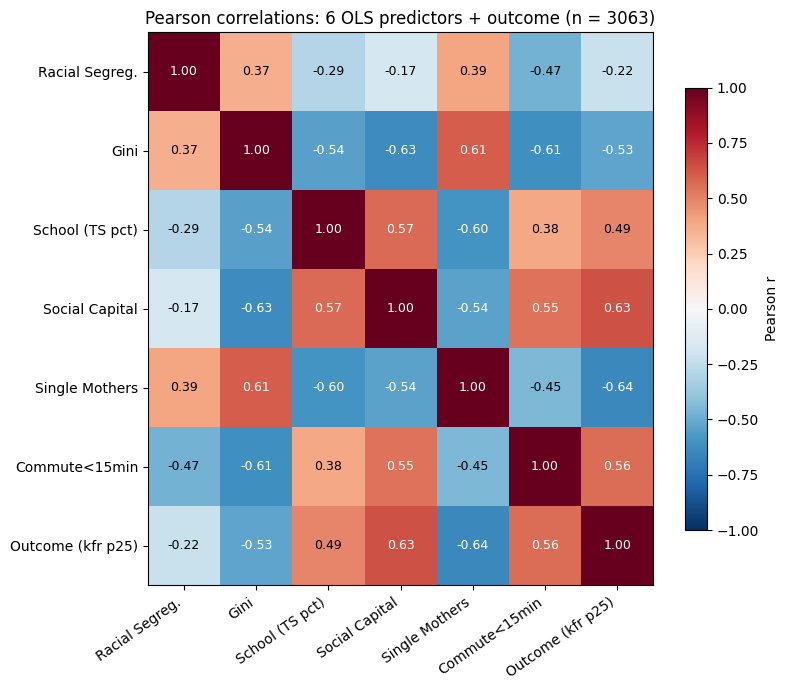

In [19]:
_cols = [
    ('Racial Segregation',                       'Racial Segreg.'),
    ('Gini',                                     'Gini'),
    ('Test Score Percentile (Income Adjusted',   'School (TS pct)'),
    ('Social Capital Index',                     'Social Capital'),
    ('Fraction of Children with Single Mothers', 'Single Mothers'),
    ('Frac. with Commute < 15 Mins',             'Commute<15min'),
    ('kfr_pooled_pooled_p25',                    'Outcome (kfr p25)'),
]
_full = [c[0] for c in _cols]
_short = [c[1] for c in _cols]

_sub = merged_df[_full].apply(pd.to_numeric, errors='coerce')
_corr = _sub.corr().values
_n = len(_sub.dropna(subset=_full))

fig, ax = plt.subplots(figsize=(8, 7))
_im = ax.imshow(_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
for i in range(len(_short)):
    for j in range(len(_short)):
        ax.text(j, i, f'{_corr[i, j]:.2f}', ha='center', va='center',
                color='black' if abs(_corr[i, j]) < 0.5 else 'white', fontsize=9)
ax.set_xticks(range(len(_short))); ax.set_yticks(range(len(_short)))
ax.set_xticklabels(_short, rotation=35, ha='right'); ax.set_yticklabels(_short)
ax.set_title(f'Pearson correlations: 6 OLS predictors + outcome (n = {_n})')
fig.colorbar(_im, ax=ax, label='Pearson r', shrink=0.8)
fig.tight_layout()

_corr_path = _proj_root / 'report' / 'predictor_correlation_heatmap.png'
_corr_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_corr_path, dpi=144, bbox_inches='tight')
print(f'saved: {_corr_path}')
plt.show()